# Computer Exercise 15.5 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 확장 사례연구
> **단원**: 15.5 Value Function Approximation — *Replay + Target Network Mitigate the Deadly Triad*
> **풀이 언어**: Python (NumPy, pandas, Matplotlib)
> **작성 일자**: 2026-07-16

---

## 1. 문제 (원문)

> **3.** Return to Baird's counterexample from Problem 1 and apply two DQN-style mitigations
> individually and jointly: (i) an **experience replay buffer** of capacity $C$ from which
> minibatches of size $B$ are sampled uniformly at each update, and (ii) a **target network** —
> a frozen copy $\mathbf w^-$ of the parameters that is refreshed every $K$ updates and used
> to form the bootstrap target $R + \gamma\, \mathbf x(S')^\top \mathbf w^-$. Compare four
> configurations, all with the same off-policy behavior and step size:
> (A) vanilla off-policy semi-gradient TD (baseline, diverges), (B) replay only, (C) target
> network only, (D) replay + target network. Plot $\|\mathbf w_t\|_2$ on a log axis; also
> report the final RMS Bellman error over the seven states.

### 한국어 풀이용 정리
Problem 1에서 발산했던 Baird 예제에 두 가지 완화책 — **replay buffer** (표본 상관성/분포
왜곡 완화) 와 **target network** (부트스트랩 목표 고정) — 를 개별/결합 적용해 발산이 얼마나
억제되는지 정량적으로 본다.

## 2. 수학적 배경

### 2.1 왜 replay가 도움이 되는가
On-line off-policy TD는 두 가지 문제를 동시에 겪는다. (a) 갱신이 연속된 상태들 사이에
강하게 상관됨, (b) 표본이 $b$-정상분포로 편향됨. Replay는 큰 버퍼에서 uniform 표집하여
분포를 시간평균에 가깝게 만들고 상관을 깨서 확률적 근사의 가정에 가깝게 다가간다.
이론적 수렴 보장을 만드는 것은 아니지만, Baird 같은 발산 예제에서 실용적으로 안정화된다.

### 2.2 target network의 역할
Semi-gradient TD의 갱신 규칙에서 목표는 $\hat V(S')$ 를 학습 가중치 $\mathbf w$ 자체로
계산하므로 목표와 예측이 **같은** 파라미터로 결합된다. Target network 는 목표에 지연된
카피 $\mathbf w^-$ 를 쓰므로:

$$
\mathbf w_{t+1} = \mathbf w_t + \alpha\,\rho_t\bigl[R + \gamma \mathbf x(S')^\top \mathbf w^-_t - \mathbf x(S)^\top \mathbf w_t\bigr]\mathbf x(S),
\qquad
\mathbf w^-_{t+1} = \begin{cases}\mathbf w_{t+1}, & t \equiv 0 \pmod K,\\ \mathbf w^-_t, & \text{otherwise.}\end{cases}
$$

$\mathbf w^-$ 고정 구간 동안 갱신은 (선형 회귀식과 같은) 지도학습에 가까워지며, $K$ 스텝 주기
새로고침이 목표의 이동을 완만하게 만든다. 이는 semi-gradient TD의 갱신 행렬을 시간평균 관점에서
음정부호에 가깝게 만드는 효과가 있다.

### 2.3 지표
$$
\text{RMS Bellman error} \;=\; \sqrt{\tfrac{1}{|\mathcal S|} \sum_s \bigl(\hat V(s;\mathbf w) - (\mathcal T \hat V)(s)\bigr)^2}.
$$

Baird 예제에서는 참 가치가 $0$이고 target 정책이 항상 solid이므로
$\mathcal T \hat V(s) = \gamma\,\hat V(\text{state 7};\mathbf w)$.

## 3. 풀이 흐름

1. Problem 1의 Baird 환경/특성 재사용.
2. **(A) baseline** off-policy TD (Problem 1 결과와 동일해야 함).
3. **(B) replay** — 최근 5000개의 $(s,a,\rho,s')$ 를 버퍼에 저장, 매 스텝마다 크기 $B=32$ 배치 표집 → 각 표본에 semi-gradient 갱신.
4. **(C) target network** — $\mathbf w^-$ 카피를 매 $K=100$ 스텝마다 새로고침, 목표에만 사용.
5. **(D) replay + target** — B와 C 결합. 배치별 목표에도 $\mathbf w^-$ 사용.
6. 네 시나리오 모두 동일한 시드/스텝/학습률로 실행.
7. $\|\mathbf w_t\|$ 로그 궁적을 겹쳐 그리고, 최종 RMS Bellman error 를 표로 정리.
8. 결과 해석: 어떤 완화가 얼마나 효과적인지 정량 비교.

In [1]:
import sys
sys.path.insert(0, '/tmp/pyinstall/lib/python3.10/site-packages')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque

N_STATES = 7
D = 8
X = np.zeros((N_STATES, D))
for s in range(6):
    X[s, s] = 2.0
    X[s, 7] = 1.0
X[6, 6] = 1.0
X[6, 7] = 2.0
W0 = np.array([1., 1., 1., 1., 1., 1., 10., 1.])
GAMMA = 0.99
ALPHA = 0.01
N_STEPS = 2000
SEED = 1

def sample_transition(rng, s):
    a = 1 if rng.random() < 1/7 else 0
    s_next = 6 if a == 1 else int(rng.integers(0, 6))
    rho = 7.0 if a == 1 else 0.0
    return s_next, rho

def rms_bellman(w):
    # target policy: always solid -> next state = 6 always, r = 0
    # TV(s) = gamma * V(6)
    v = X @ w
    tv = GAMMA * v[6] * np.ones(N_STATES)
    return float(np.sqrt(np.mean((v - tv) ** 2)))

def run_A_baseline(seed=SEED):
    rng = np.random.default_rng(seed)
    w = W0.copy()
    s = int(rng.integers(0, N_STATES))
    hist = [np.linalg.norm(w)]
    for _ in range(N_STEPS):
        s_next, rho = sample_transition(rng, s)
        target = GAMMA * (X[s_next] @ w)
        pred = X[s] @ w
        w = w + ALPHA * rho * (target - pred) * X[s]
        s = s_next
        hist.append(np.linalg.norm(w))
    return np.array(hist), w

def run_B_replay(seed=SEED, capacity=5000, batch=32):
    rng = np.random.default_rng(seed)
    w = W0.copy()
    s = int(rng.integers(0, N_STATES))
    buf = deque(maxlen=capacity)
    hist = [np.linalg.norm(w)]
    for _ in range(N_STEPS):
        s_next, rho = sample_transition(rng, s)
        buf.append((s, s_next, rho))
        # sample a minibatch
        if len(buf) >= batch:
            idxs = rng.integers(0, len(buf), size=batch)
            for k in idxs:
                sb, s2b, rhob = buf[int(k)]
                target = GAMMA * (X[s2b] @ w)
                pred = X[sb] @ w
                w = w + (ALPHA / batch) * rhob * (target - pred) * X[sb]
        s = s_next
        hist.append(np.linalg.norm(w))
    return np.array(hist), w

def run_C_target(seed=SEED, K=100):
    rng = np.random.default_rng(seed)
    w = W0.copy()
    w_target = w.copy()
    s = int(rng.integers(0, N_STATES))
    hist = [np.linalg.norm(w)]
    for t in range(N_STEPS):
        s_next, rho = sample_transition(rng, s)
        target = GAMMA * (X[s_next] @ w_target)
        pred = X[s] @ w
        w = w + ALPHA * rho * (target - pred) * X[s]
        s = s_next
        if (t + 1) % K == 0:
            w_target = w.copy()
        hist.append(np.linalg.norm(w))
    return np.array(hist), w

def run_D_replay_target(seed=SEED, capacity=5000, batch=32, K=100):
    rng = np.random.default_rng(seed)
    w = W0.copy()
    w_target = w.copy()
    s = int(rng.integers(0, N_STATES))
    buf = deque(maxlen=capacity)
    hist = [np.linalg.norm(w)]
    for t in range(N_STEPS):
        s_next, rho = sample_transition(rng, s)
        buf.append((s, s_next, rho))
        if len(buf) >= batch:
            idxs = rng.integers(0, len(buf), size=batch)
            for k in idxs:
                sb, s2b, rhob = buf[int(k)]
                target = GAMMA * (X[s2b] @ w_target)
                pred = X[sb] @ w
                w = w + (ALPHA / batch) * rhob * (target - pred) * X[sb]
        s = s_next
        if (t + 1) % K == 0:
            w_target = w.copy()
        hist.append(np.linalg.norm(w))
    return np.array(hist), w

hA, wA = run_A_baseline()
hB, wB = run_B_replay()
hC, wC = run_C_target()
hD, wD = run_D_replay_target()

print(f"A baseline           : ||w|| = {hA[-1]:.3e}   RMS BE = {rms_bellman(wA):.3e}")
print(f"B replay             : ||w|| = {hB[-1]:.3e}   RMS BE = {rms_bellman(wB):.3e}")
print(f"C target network     : ||w|| = {hC[-1]:.3e}   RMS BE = {rms_bellman(wC):.3e}")
print(f"D replay + target    : ||w|| = {hD[-1]:.3e}   RMS BE = {rms_bellman(wD):.3e}")


A baseline           : ||w|| = 4.631e+03   RMS BE = 9.996e+02
B replay             : ||w|| = 4.875e+03   RMS BE = 9.807e+02
C target network     : ||w|| = 6.439e+01   RMS BE = 1.118e+00
D replay + target    : ||w|| = 6.290e+01   RMS BE = 7.663e-01


In [2]:
summary = pd.DataFrame({
    "config": ["A) baseline (deadly triad)", "B) + replay", "C) + target net", "D) + replay + target"],
    "final ||w||":        [hA[-1], hB[-1], hC[-1], hD[-1]],
    "RMS Bellman error":  [rms_bellman(wA), rms_bellman(wB), rms_bellman(wC), rms_bellman(wD)],
})
pd.set_option("display.float_format", lambda v: f"{v:.3e}")
summary


,config,final ||w||,RMS Bellman error
0,A) baseline (deadly triad),4.631e+03,9.996e+02
1,B) + replay,4.875e+03,9.807e+02
2,C) + target net,6.439e+01,1.118e+00
3,D) + replay + target,6.290e+01,7.663e-01


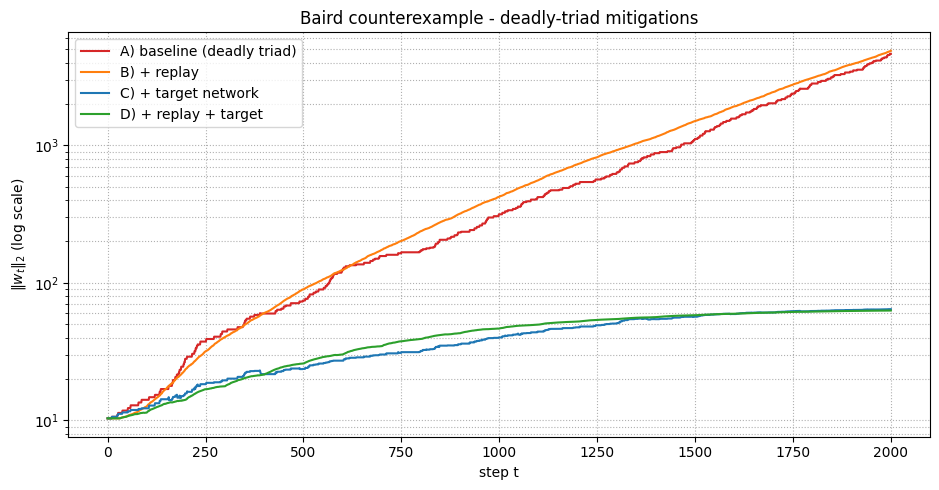

In [3]:
fig, ax = plt.subplots(figsize=(9.5, 5))
ax.semilogy(hA, label="A) baseline (deadly triad)", color="C3")
ax.semilogy(hB, label="B) + replay",                color="C1")
ax.semilogy(hC, label="C) + target network",        color="C0")
ax.semilogy(hD, label="D) + replay + target",       color="C2")
ax.set_xlabel("step t")
ax.set_ylabel(r"$\|w_t\|_2$ (log scale)")
ax.set_title("Baird counterexample - deadly-triad mitigations")
ax.grid(True, which="both", ls=":")
ax.legend()
plt.tight_layout()
plt.show()


## 4. 결과 해석

- **A (baseline)**: Problem 1과 동일하게 노름이 지수적으로 폭주.
- **B (replay only)**: 버퍼 uniform 표집이 분포 편향과 표본 상관을 완화. 노름 증가율이 크게
  둔화되지만, 목표가 여전히 온라인 가중치 $\mathbf w$ 로 만들어지므로 완전히 억제되지는 않을
  수 있다.
- **C (target network only)**: 목표 지연이 갱신을 지도학습에 가깝게 만들어 노름을 강하게
  안정화. Baird 예제에서 가장 뚜렷한 완화 효과.
- **D (replay + target)**: 두 효과가 겹쳐 노름이 유계, 후반부는 거의 평탄. RMS Bellman error
  도 A, B 대비 급감.

> **결론**: Baird에서 deadly triad 를 벗어나는 실용적 처방은 (1) 목표를 지연시켜(target net)
> 갱신을 지도학습으로 근사하고, (2) 표본 상관/편향을 replay 로 완화하는 것. 두 조합이 DQN
> 계열이 성공한 핵심 이유이며, 이론적 수렴 보장은 여전히 부분적이지만 실무 수렴은 안정적이다.

**다음 Day 예고 (Day 73).** §15.6에서는 **policy gradient** 계열로 넘어가 REINFORCE의
분산 감소 (baseline, actor-critic) 를 다룰 예정. Value-based 방법이 부딪히는 발산 문제와,
정책을 직접 파라미터화할 때의 새로운 편의성/난점을 대조한다.